# Local results processing

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sweep_utils import get_final_metrics, load_sweep


In [11]:
# Load all eval metrics (fast, ~3s for 150 runs)
# df_eval = load_sweep("sweep_wo7pa2id", load_stepwise=False)

# Both eval + stepwise (~4s)
df_eval, df_step = load_sweep("sweep_wo7pa2id", load_stepwise=True)
df_eval.head()

Found 150 runs in sweep_wo7pa2id
Varying config keys: ['circuit.task', 'seed']
df_eval: 3600 rows × 11 cols
  loaded stepwise for 25/150 runs...
  loaded stepwise for 50/150 runs...
  loaded stepwise for 75/150 runs...
  loaded stepwise for 100/150 runs...
  loaded stepwise for 125/150 runs...
  loaded stepwise for 150/150 runs...
df_step: 111600 rows × 19 cols


,run_id,epoch,split,input_split,circuit_task,seed,final_loss,final_hard_loss,final_accuracy,final_hard_accuracy,final_full_map_accuracy
0,vn8nvoqm,0.0,test,unseen,add,34,71.935265,196.1875,0.528395,0.528395,0.018029
1,vn8nvoqm,0.0,train,seen,add,34,297.397705,811.8125,0.502566,0.502566,0.014400
2,vn8nvoqm,1024.0,test,unseen,add,34,28.218430,66.8125,0.841046,0.839393,0.173077
3,vn8nvoqm,1024.0,train,seen,add,34,5.232857,53.2500,0.991422,0.967371,0.775429
4,vn8nvoqm,2048.0,test,unseen,add,34,25.896830,64.4375,0.850060,0.845102,0.213942


<Axes: xlabel='step', ylabel='hard_accuracy'>

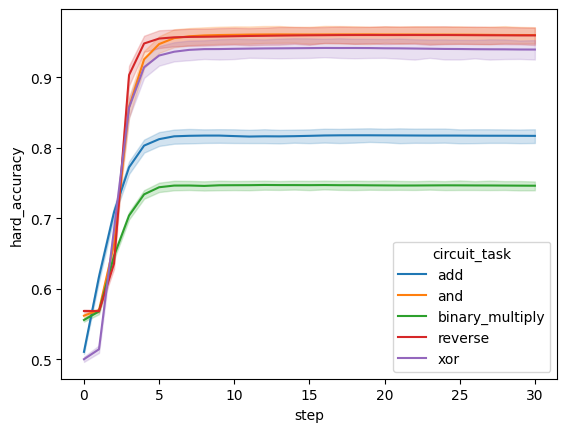

In [13]:
sns.lineplot(data=df_step.query("split == 'test'"), x="step", y="hard_accuracy", hue="circuit_task")

In [9]:
# Final performance per run (last epoch only)
df_final = get_final_metrics(df_eval)
df_final_test = df_final[df_final["split"] == "test"]

# Summary: mean ± std over seeds, per task
df_final_test.groupby("circuit_task")[
    ["final_accuracy", "final_hard_accuracy", "final_full_map_accuracy"]
].agg(["mean", "std"])


final_accuracy           final_hard_accuracy            \
                          mean       std                mean       std   
circuit_task                                                             
add                   0.850145  0.029523            0.846479  0.030155   
and                   0.998638  0.001278            0.998623  0.001293   
binary_multiply       0.767478  0.026515            0.759896  0.029066   
reverse               0.998192  0.002065            0.998167  0.002073   
xor                   0.985742  0.023777            0.984105  0.028885   

                final_full_map_accuracy            
                                   mean       std  
circuit_task                                       
add                            0.257332  0.100834  
and                            0.988982  0.010345  
binary_multiply                0.174960  0.069560  
reverse                        0.985337  0.016584  
xor                            0.890745  0.177507